In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Load output CSVs
llama_df = pd.read_csv("/content/p12_mistral_results_with_author.csv")
mistral_df = pd.read_csv("/content/p12_llama_results_with_author.csv")
gemini_df = pd.read_csv("/content/p12_gemini_2_5_pro_results_author.csv")

# Pack into a dictionary for looping
models = {
    "LLaMA": llama_df,
    "Mistral": mistral_df,
    "Gemini": gemini_df
}

# Normalize labels
for name, df in models.items():
    df["orig"] = df["original_true_false"].astype(str).str.lower().str.strip()
    df["pred"] = df["statement_verification_label"].astype(str).str.lower().str.strip()



===== FACT LABEL DISTRIBUTION (PERCENTAGES) =====



,LLaMA,Mistral,Gemini
low,9.23,20.37,14.25
medium,27.26,24.73,17.43
high,63.51,54.90,68.32


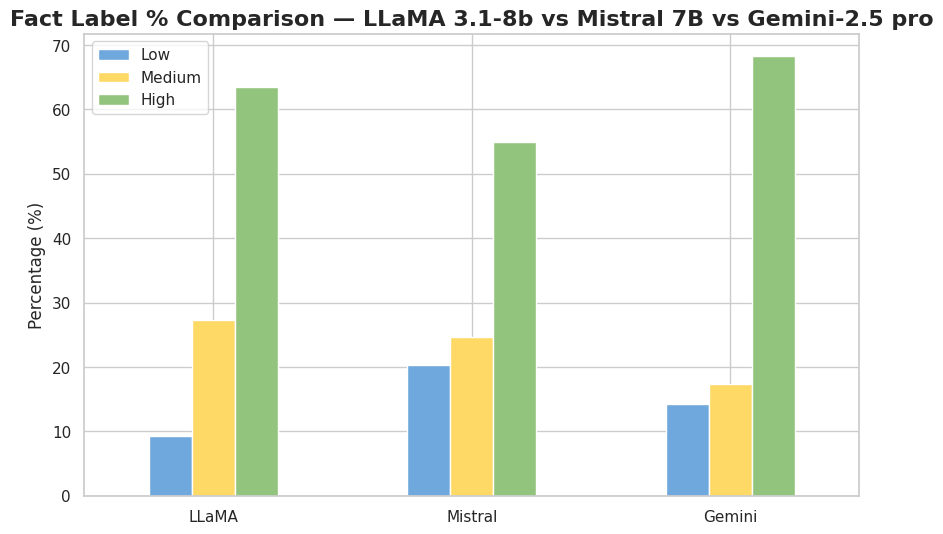

In [3]:
def collect_fact_labels(df):
    labels = pd.concat([df["fact1_label"], df["fact2_label"], df["fact3_label"]])
    labels = labels.str.lower()
    labels = labels[labels.isin(["low","medium","high"])]
    return labels.value_counts().reindex(["low","medium","high"], fill_value=0)

fact_data = {}
for name, df in models.items():
    counts = collect_fact_labels(df)
    pct = (counts / counts.sum() * 100).round(2)
    fact_data[name] = pct

fact_compare = pd.DataFrame(fact_data)
print("\n===== FACT LABEL DISTRIBUTION (PERCENTAGES) =====\n")
display(fact_compare)

# Plot
colors = ["#6FA8DC", "#FFD966", "#93C47D"]  # soft blue, yellow, green

fact_compare.T.plot(kind="bar", figsize=(10,6), color=colors)
plt.title("Fact Label % Comparison — LLaMA 3.1-8b vs Mistral 7B vs Gemini-2.5 pro", fontsize=16, weight="bold")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["Low", "Medium", "High"])
plt.show()


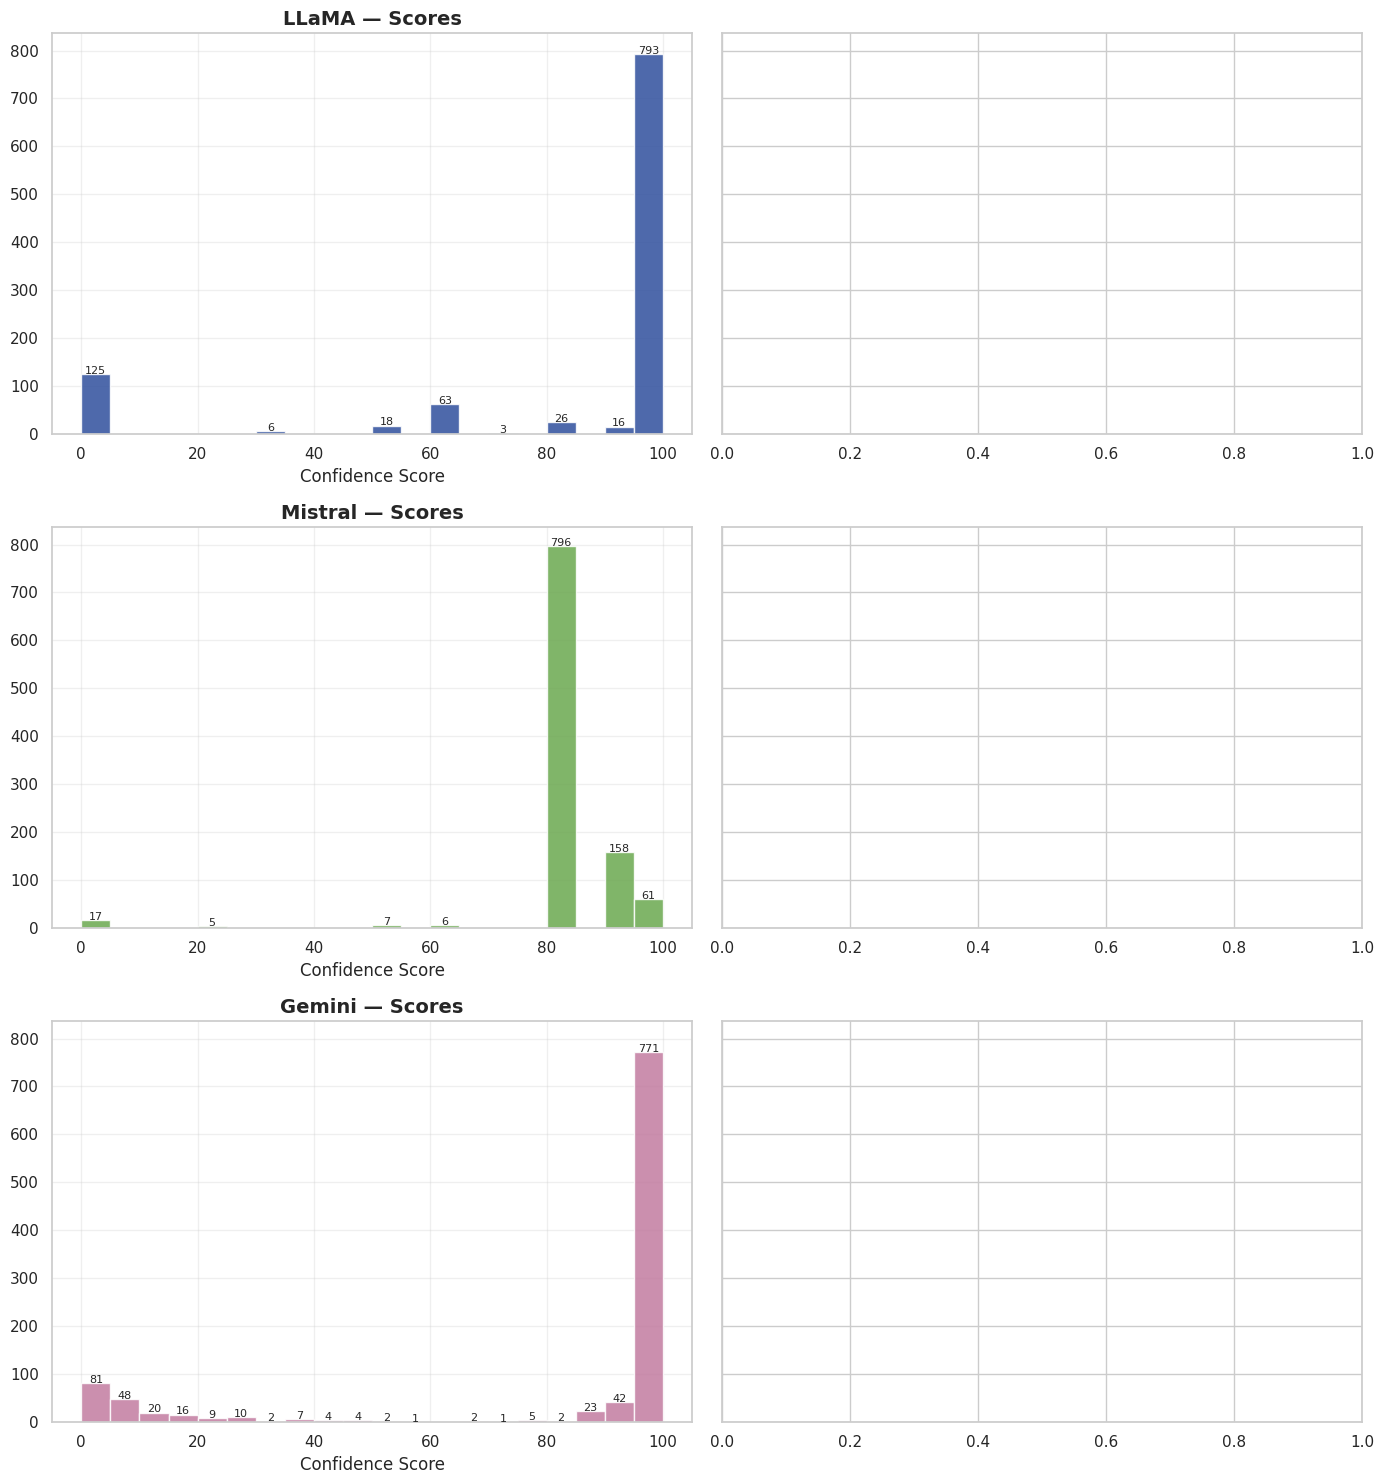

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14,15), sharey=True)

colors = {
    "LLaMA": "#2F4F9D",
    "Mistral": "#6AA84F",
    "Gemini": "#C27BA0"
}

def hist_with_labels(ax, data, title, color):
    counts, bins, patches = ax.hist(data, bins=20, color=color, alpha=0.85)
    for count, left, right in zip(counts, bins[:-1], bins[1:]):
        if count > 0:
            ax.text((left+right)/2, count+0.5, str(int(count)), ha="center", fontsize=8)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Confidence Score")
    ax.grid(alpha=0.3)

row = 0
for model, df in models.items():
    hist_with_labels(axes[row][0], df["chosen_fact_score"], f"{model} — Scores", colors[model])
    row += 1

plt.tight_layout()
plt.show()


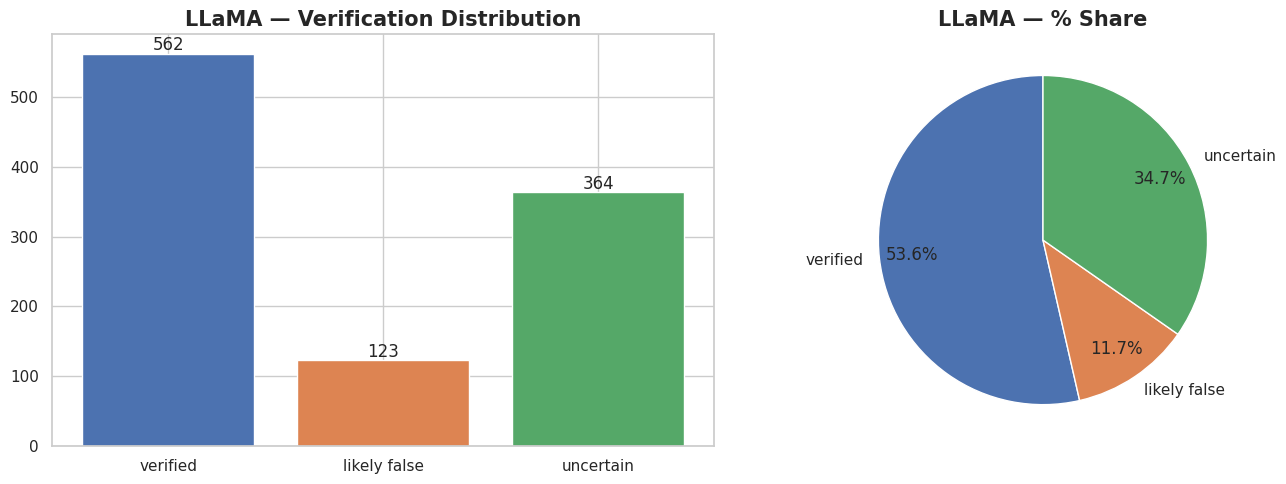

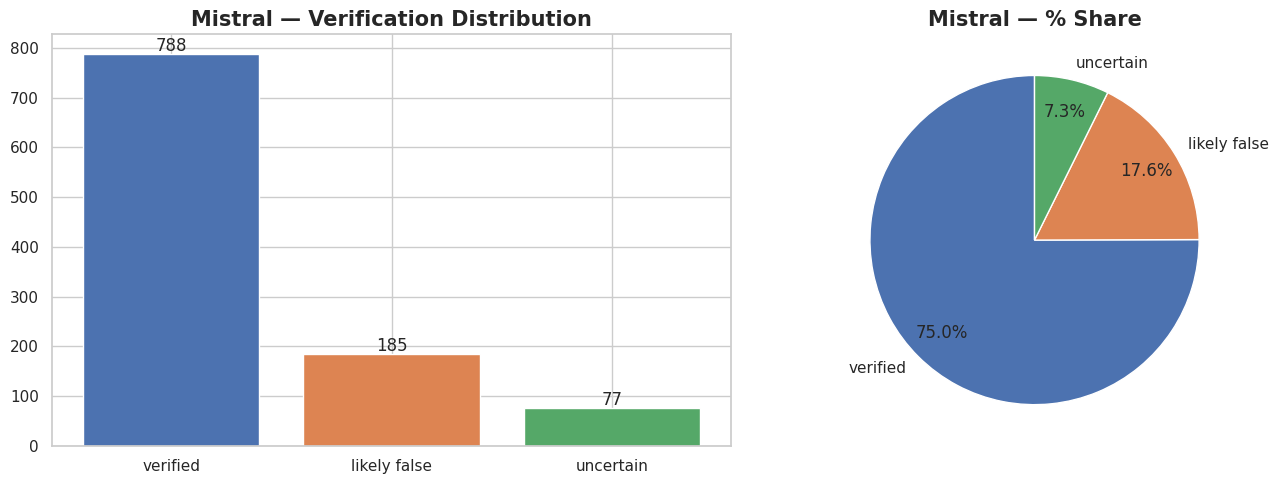

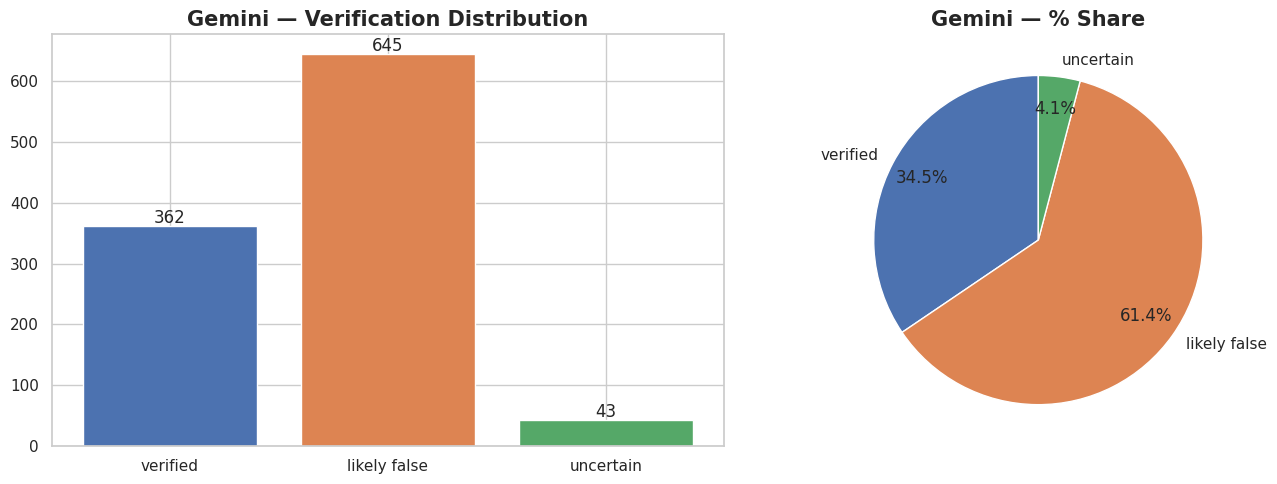

In [5]:
labels = ["verified","likely false","uncertain"]
bar_colors = ["#4C72B0","#DD8452","#55A868"]

for model, df in models.items():
    vc = df["pred"].value_counts().reindex(labels, fill_value=0)

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # BAR CHART
    axes[0].bar(labels, vc.values, color=bar_colors)
    for i, v in enumerate(vc.values):
        axes[0].text(i, v+5, str(v), ha="center")
    axes[0].set_title(f"{model} — Verification Distribution", fontsize=15, weight="bold")

    # PIE CHART
    axes[1].pie(vc.values, labels=labels, autopct="%1.1f%%", startangle=90,
                colors=bar_colors, pctdistance=0.8)
    axes[1].set_title(f"{model} — % Share", fontsize=15, weight="bold")

    plt.tight_layout()
    plt.show()


In [6]:
for model, df in models.items():
    print(f"\n===== ACCURACY — {model} =====\n")

    eval_df = df[df["pred"] != "uncertain"]

    correct = (
        ((eval_df["orig"] == "true") & (eval_df["pred"] == "verified")) |
        ((eval_df["orig"] == "false") & (eval_df["pred"] == "likely false"))
    ).sum()

    accuracy = correct / len(eval_df)

    print(f"Evaluated samples: {len(eval_df)}")
    print(f"Correct predictions: {correct}")
    print(f"Accuracy: {accuracy:.4f}\n")



===== ACCURACY — LLaMA =====

Evaluated samples: 686
Correct predictions: 339
Accuracy: 0.4942


===== ACCURACY — Mistral =====

Evaluated samples: 973
Correct predictions: 477
Accuracy: 0.4902


===== ACCURACY — Gemini =====

Evaluated samples: 1007
Correct predictions: 845
Accuracy: 0.8391



In [7]:
for model, df in models.items():
    print(f"\n===== CONFUSION TABLE — {model} =====\n")
    ct = pd.crosstab(df["orig"], df["pred"])
    display(ct)



===== CONFUSION TABLE — LLaMA =====



pred,likely false,likely true,uncertain,verified
orig,,,,
false,117,1,284,340
true,6,0,80,222



===== CONFUSION TABLE — Mistral =====



pred,likely false,uncertain,verified
orig,,,
false,180,71,491
true,5,6,297



===== CONFUSION TABLE — Gemini =====



pred,likely false,uncertain,verified
orig,,,
false,596,33,113
true,49,10,249


In [8]:
def build_table(df):
    ct = pd.crosstab(df["orig"], df["pred"]).reindex(["false","true"], fill_value=0)
    return ct

lama_ct = build_table(llama_df)
mistral_ct = build_table(mistral_df)
gemini_ct = build_table(gemini_df)

comparison = pd.DataFrame({
    "Category": [
        "False → Verified", "False → Likely False", "False → Uncertain",
        "True → Verified",  "True → Likely False",  "True → Uncertain"
    ],
    "LLaMA": [
        lama_ct.loc["false","verified"],
        lama_ct.loc["false","likely false"],
        lama_ct.loc["false","uncertain"],
        lama_ct.loc["true","verified"],
        lama_ct.loc["true","likely false"],
        lama_ct.loc["true","uncertain"]
    ],
    "Mistral": [
        mistral_ct.loc["false","verified"],
        mistral_ct.loc["false","likely false"],
        mistral_ct.loc["false","uncertain"],
        mistral_ct.loc["true","verified"],
        mistral_ct.loc["true","likely false"],
        mistral_ct.loc["true","uncertain"]
    ],
    "Gemini": [
        gemini_ct.loc["false","verified"],
        gemini_ct.loc["false","likely false"],
        gemini_ct.loc["false","uncertain"],
        gemini_ct.loc["true","verified"],
        gemini_ct.loc["true","likely false"],
        gemini_ct.loc["true","uncertain"]
    ]
})

print("\n========== 📌 FINAL SIDE-BY-SIDE COMPARISON (ALL 3 MODELS) ==========\n")
display(comparison)



========== 📌 FINAL SIDE-BY-SIDE COMPARISON (ALL 3 MODELS) ==========



,Category,LLaMA,Mistral,Gemini
0,False → Verified,340,491,113
1,False → Likely False,117,180,596
2,False → Uncertain,284,71,33
3,True → Verified,222,297,249
4,True → Likely False,6,5,49
5,True → Uncertain,80,6,10


In [9]:
def original_truth_summary(df, model_name):

    # Normalize labels
    df["orig"] = df["original_true_false"].astype(str).str.lower().str.strip()
    df["pred"] = df["statement_verification_label"].str.lower().str.strip()

    # Standardize prediction labels
    df["pred"] = df["pred"].replace({
        "verified": "Verified",
        "likely false": "Likely False",
        "uncertain": "Uncertain"
    })

    # Total count for each class
    total_true = (df["orig"] == "true").sum()
    total_false = (df["orig"] == "false").sum()

    # Build matrix
    table = pd.crosstab(df["orig"], df["pred"]).reindex(["true", "false"])
    table = table.reindex(columns=["Verified", "Likely False", "Uncertain"], fill_value=0)

    # Insert NEW column at start
    table.insert(0, "original_total_count", [total_true, total_false])

    print(f"\n===== ORIGINAL TRUE/FALSE WITH TOTALS FIRST — {model_name} =====\n")
    display(table)

    return table


# Example usage:
lama_truth = original_truth_summary(llama_df, "LLaMA 3.1 8B")
mistral_truth = original_truth_summary(mistral_df, "Mistral 7B")
gemini_truth = original_truth_summary(gemini_df, "Gemini 2.5 pro")



===== ORIGINAL TRUE/FALSE WITH TOTALS FIRST — LLaMA 3.1 8B =====



pred,original_total_count,Verified,Likely False,Uncertain
orig,,,,
true,308,222,6,80
false,742,340,117,284



===== ORIGINAL TRUE/FALSE WITH TOTALS FIRST — Mistral 7B =====



pred,original_total_count,Verified,Likely False,Uncertain
orig,,,,
true,308,297,5,6
false,742,491,180,71



===== ORIGINAL TRUE/FALSE WITH TOTALS FIRST — Gemini 2.5 pro =====



pred,original_total_count,Verified,Likely False,Uncertain
orig,,,,
true,308,249,49,10
false,742,113,596,33
